# Clasificación y Regresión con Scikit-Learn
última actualización: 2026

## Introducción
Este notebook recorre los conceptos fundamentales del ML supervisado usando exclusivamente **Scikit-Learn**. Cubriremos:

1. **Regresión Lineal** — aprender la relación $y = wx + b$ desde datos
2. **Clasificación Binaria** — separar dos clases usando fronteras de decisión
3. **Clasificación Multiclase** — reconocimiento de dígitos escritos a mano con **MNIST**

En cada sección veremos cómo sklearn aprende los parámetros, cómo visualizar los resultados y cómo evaluarlos correctamente.

<hr/>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">
[Consejo]: Ejecuta cada celda con <kbd>Shift</kbd> + <kbd>Enter</kbd> en orden.
</div>
<hr/>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model    import LinearRegression, LogisticRegression
from sklearn.neural_network  import MLPClassifier,MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.datasets        import fetch_openml, make_classification
from sklearn.preprocessing   import StandardScaler

from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

sns.set_theme(style='whitegrid', font_scale=1.1)
np.random.seed(42)

import sklearn
print('scikit-learn:', sklearn.__version__)

scikit-learn: 1.7.2


---
# PARTE 1: Regresión Lineal — Y(x) = w·x + b

La tarea más simple del aprendizaje supervisado: dado un conjunto de pares $(x_i, y_i)$, encontrar los parámetros $w$ (pendiente) y $b$ (intercepto) que mejor describen la relación lineal entre ellos.

**Sklearn aprende** estos parámetros minimizando el Error Cuadrático Medio:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \sum_{i=1}^{n} (y_i - (wx_i + b))^2$$

## 1.1 Generación de datos sintéticos

Creamos datos con una relación lineal conocida más ruido gaussiano:
$$y = w_{real} \cdot x + b_{real} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$$

El objetivo del modelo será **recuperar** $w_{real}$ y $b_{real}$ a partir de los datos ruidosos.

Parámetros verdaderos: w=5.5, b=2.3
Rango de x: [-10.0, 10.0]
Rango de y: [-52.62, 57.72]


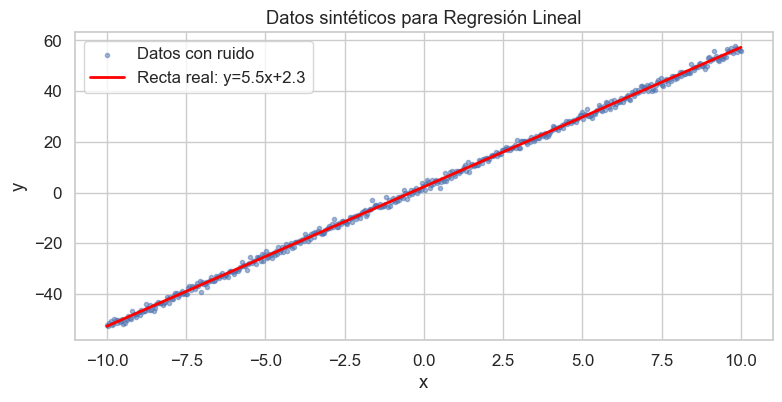

In [2]:
w_real = 5.5    
b_real = 2.3   
sigma  = 1.0    
n      = 500  

# Generar datos
x = np.linspace(-10.0, 10.0, n)
ruido = np.random.normal(loc=0.0, scale=sigma, size=n)
y = w_real * x + b_real + ruido

print(f'Parámetros verdaderos: w={w_real}, b={b_real}')
print(f'Rango de x: [{x.min():.1f}, {x.max():.1f}]')
print(f'Rango de y: [{y.min():.2f}, {y.max():.2f}]')

plt.figure(figsize=(9, 4))
plt.scatter(x, y, marker='.', alpha=0.5, label='Datos con ruido')
plt.plot(x, w_real*x + b_real, color='red', linewidth=2, label=f'Recta real: y={w_real}x+{b_real}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Datos sintéticos para Regresión Lineal')
plt.legend()
plt.show()

## 1.2 Partición Train / Validation / Test

In [3]:
X = x.reshape(-1, 1)   # forma: (300, 1)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42
)

print(f'Train:      {len(X_train)} muestras ({len(X_train)/n*100:.0f}%)')
print(f'Validation: {len(X_val)}  muestras ({len(X_val)/n*100:.0f}%)')
print(f'Test:       {len(X_test)}  muestras ({len(X_test)/n*100:.0f}%)')

Train:      350 muestras (70%)
Validation: 75  muestras (15%)
Test:       75  muestras (15%)


## 1.3 Entrenamiento del modelo

La interfaz de sklearn es siempre la misma:
1. **Instanciar** el modelo
2. **`fit(X_train, y_train)`** → aprende $w$ y $b$
3. **`predict(X)`** → aplica el modelo aprendido

In [4]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

w_aprendido = modelo.coef_[0]    
b_aprendido = modelo.intercept_     

print('═══ Comparación: real vs aprendido ═══')
print(f'  Pendiente  w: real={w_real:.4f}  →  aprendido={w_aprendido:.4f}')
print(f'  Intercepto b: real={b_real:.4f}  →  aprendido={b_aprendido:.4f}')
print('═════════════════════')
modelomlp = MLPRegressor(hidden_layer_sizes=1,activation='identity',max_iter=100000,learning_rate_init=1e-3)
modelomlp.fit(X_train, y_train)

w_aprendido = modelomlp.coefs_[1][0][0] * modelomlp.coefs_[0][0][0]
b_aprendido = modelomlp.coefs_[1][0][0] * modelomlp.intercepts_[0][0] +modelomlp.intercepts_[1][0]
print('═══ Comparación MLP: real vs aprendido ═══')
print(f'  Peso  w: real={w_real:.4f}  →  aprendido={w_aprendido:.4f}')
print(f'  Bias b: real={b_real:.4f}  →  aprendido={b_aprendido:.4f}')  



═══ Comparación: real vs aprendido ═══
  Pendiente  w: real=5.5000  →  aprendido=5.5017
  Intercepto b: real=2.3000  →  aprendido=2.2765
═════════════════════
═══ Comparación MLP: real vs aprendido ═══
  Peso  w: real=5.5000  →  aprendido=5.4882
  Bias b: real=2.3000  →  aprendido=2.2722


## 1.4 Evaluación y visualización

── Métricas ──────────────────────────────
  MSE  Train:      0.9135
  MSE  Validation: 1.1276
  R²   Train:      0.9990
  R²   Validation: 0.9989


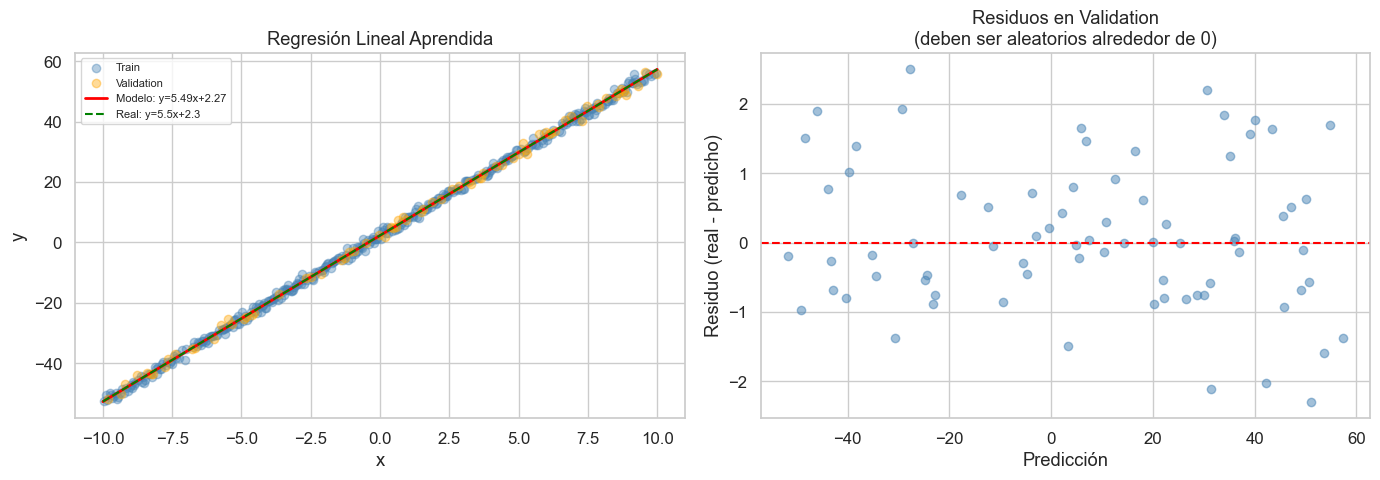

In [5]:

y_pred_train = modelo.predict(X_train)
y_pred_val   = modelo.predict(X_val)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_val   = mean_squared_error(y_val,   y_pred_val)
r2_train  = r2_score(y_train, y_pred_train)
r2_val    = r2_score(y_val,   y_pred_val)

print('── Métricas ──────────────────────────────')
print(f'  MSE  Train:      {mse_train:.4f}')
print(f'  MSE  Validation: {mse_val:.4f}')
print(f'  R²   Train:      {r2_train:.4f}')
print(f'  R²   Validation: {r2_val:.4f}')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


x_linea = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
y_linea = modelo.predict(x_linea)

axes[0].scatter(X_train, y_train, alpha=0.4, label='Train', color='steelblue')
axes[0].scatter(X_val,   y_val,   alpha=0.4, label='Validation', color='orange')
axes[0].plot(x_linea, y_linea, color='red', linewidth=2,
             label=f'Modelo: y={w_aprendido:.2f}x+{b_aprendido:.2f}')
axes[0].plot(x_linea, w_real*x_linea + b_real, color='green', linewidth=1.5,
             linestyle='--', label=f'Real: y={w_real}x+{b_real}')
axes[0].set_title('Regresión Lineal Aprendida')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend(fontsize=8)


residuos_val = y_val - y_pred_val
axes[1].scatter(y_pred_val, residuos_val, alpha=0.5, color='steelblue')
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Residuos en Validation\n(deben ser aleatorios alrededor de 0)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Residuo (real - predicho)')

plt.tight_layout()
plt.show()

---
# PARTE 2: Clasificación Binaria

Ahora la tarea es **predecir una etiqueta de clase** (0 ó 1) en lugar de un valor continuo. Usamos **Regresión Logística**, que modela la probabilidad de pertenencia a la clase positiva.

La frontera de decisión es donde $P(y=1|x) = 0.5$, es decir, donde el **log-odds = 0**.

## 2.1 Dataset: dos clases en 2D

Generamos datos bidimensionales para poder **visualizar la frontera de decisión**.

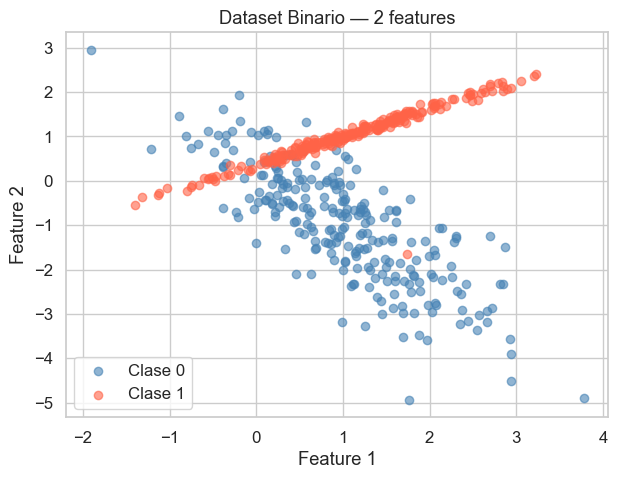

Forma de X: (500, 2)
Clases: [0 1]  |  Distribución: [249 251]


In [6]:
X_bin, y_bin = make_classification(
    n_samples=500, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

plt.figure(figsize=(7, 5))
plt.scatter(X_bin[y_bin==0, 0], X_bin[y_bin==0, 1],
            alpha=0.6, label='Clase 0', color='steelblue')
plt.scatter(X_bin[y_bin==1, 0], X_bin[y_bin==1, 1],
            alpha=0.6, label='Clase 1', color='tomato')
plt.title('Dataset Binario — 2 features')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

print(f'Forma de X: {X_bin.shape}')
print(f'Clases: {np.unique(y_bin)}  |  Distribución: {np.bincount(y_bin)}')

## 2.2 Entrenamiento y frontera de decisión

In [7]:

X_tr, X_te, y_tr, y_te = train_test_split(
    X_bin, y_bin, test_size=0.25, random_state=42, stratify=y_bin
)


scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)


clf_bin = LogisticRegression(random_state=42)
clf_bin.fit(X_tr_sc, y_tr)

print(f'Metricas en Test LR: {classification_report(y_te, clf_bin.predict(X_te_sc))}')

clf_mlp = MLPClassifier(hidden_layer_sizes=(4,6,4),random_state=40)
clf_mlp.fit(X_tr_sc, y_tr)

print(f'Metricas en Test MLP: {classification_report(y_te, clf_mlp.predict(X_te_sc))}')

Metricas en Test LR:               precision    recall  f1-score   support

           0       0.93      0.85      0.89        62
           1       0.87      0.94      0.90        63

    accuracy                           0.90       125
   macro avg       0.90      0.90      0.90       125
weighted avg       0.90      0.90      0.90       125

Metricas en Test MLP:               precision    recall  f1-score   support

           0       1.00      0.85      0.92        62
           1       0.88      1.00      0.93        63

    accuracy                           0.93       125
   macro avg       0.94      0.93      0.93       125
weighted avg       0.94      0.93      0.93       125



c:\Users\javier\Documents\escuela_ML_2026\Machine_Learning_Intro\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [8]:
def graficar_frontera(modelo, X_sc, y, scaler, titulo='Frontera de Decisión'):
    h = 0.05
    x_min, x_max = X_sc[:, 0].min() - 1, X_sc[:, 0].max() + 1
    y_min, y_max = X_sc[:, 1].min() - 1, X_sc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.contour(xx, yy, Z, colors='black', linewidths=1.5)
    plt.scatter(X_sc[y==0, 0], X_sc[y==0, 1], color='steelblue',
                alpha=0.7, label='Clase 0', edgecolors='k', linewidths=0.3)
    plt.scatter(X_sc[y==1, 0], X_sc[y==1, 1], color='tomato',
                alpha=0.7, label='Clase 1', edgecolors='k', linewidths=0.3)
    plt.title(titulo)
    plt.xlabel('Feature 1 (escalada)')
    plt.ylabel('Feature 2 (escalada)')
    plt.legend()
    plt.tight_layout()
    plt.show()

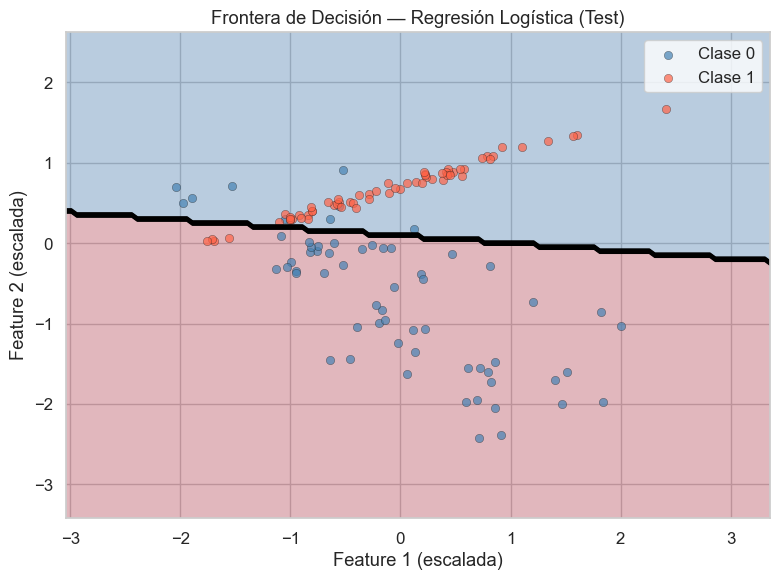

In [9]:
graficar_frontera(clf_bin, X_te_sc, y_te, scaler,
                  'Frontera de Decisión — Regresión Logística (Test)')

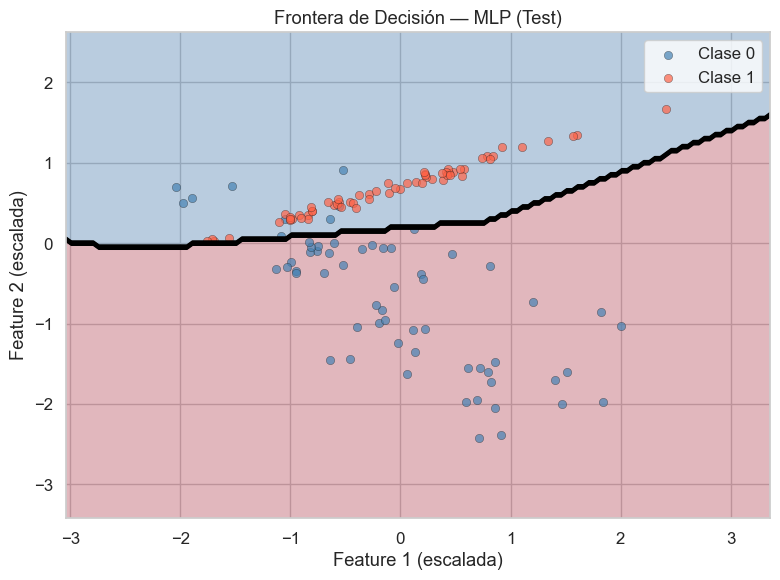

In [10]:
graficar_frontera(clf_mlp, X_te_sc, y_te, scaler,
                  'Frontera de Decisión — MLP (Test)')

## 2.3 Métricas de clasificación binaria

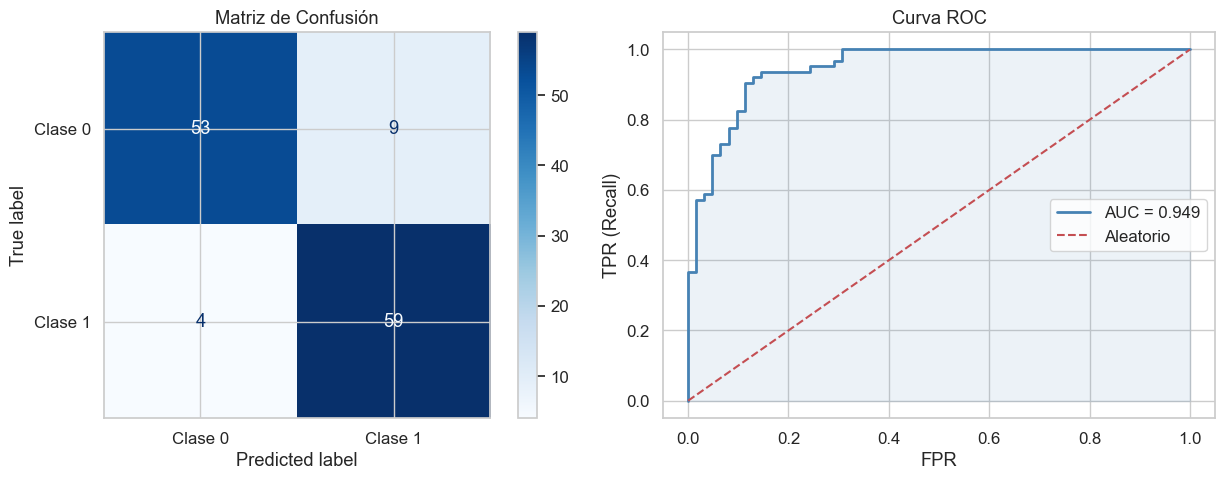

              precision    recall  f1-score   support

     Clase 0       0.93      0.85      0.89        62
     Clase 1       0.87      0.94      0.90        63

    accuracy                           0.90       125
   macro avg       0.90      0.90      0.90       125
weighted avg       0.90      0.90      0.90       125



In [11]:
y_pred_bin  = clf_bin.predict(X_te_sc)
y_prob_bin  = clf_bin.predict_proba(X_te_sc)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_bin,
    display_labels=['Clase 0', 'Clase 1'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')

fpr, tpr, _ = roc_curve(y_te, y_prob_bin)
auc = roc_auc_score(y_te, y_prob_bin)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1],'r--', linewidth=1.5, label='Aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR (Recall)')
axes[1].set_title('Curva ROC')
axes[1].legend()

plt.tight_layout()
plt.show()

print(classification_report(y_te, y_pred_bin, target_names=['Clase 0', 'Clase 1']))

---
# PARTE 3: Clasificación Multiclase con MNIST

**MNIST** es el dataset de referencia en visión por computadora. Contiene **70.000 imágenes** de dígitos escritos a mano (0–9), cada una de **28×28 píxeles = 784 features**.

Es un problema de **clasificación multiclase** con **10 clases**.

## 3.1 Carga del dataset

In [12]:
print('Descargando MNIST... (puede tardar 1-2 min la primera vez)')
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X_mnist = mnist.data.astype(np.float32)    # píxeles: valores 0-255
y_mnist = mnist.target.astype(int)         # etiquetas: 0-9

print(f'Forma de X: {X_mnist.shape}  ← {X_mnist.shape[0]} imágenes de {X_mnist.shape[1]} píxeles')
print(f'Forma de y: {y_mnist.shape}')
print(f'Clases: {np.unique(y_mnist)}')
print(f'\nDistribución de clases:')
for clase, count in zip(*np.unique(y_mnist, return_counts=True)):
    print(f'  Dígito {clase}: {count} imágenes')

Descargando MNIST... (puede tardar 1-2 min la primera vez)
Forma de X: (70000, 784)  ← 70000 imágenes de 784 píxeles
Forma de y: (70000,)
Clases: [0 1 2 3 4 5 6 7 8 9]

Distribución de clases:
  Dígito 0: 6903 imágenes
  Dígito 1: 7877 imágenes
  Dígito 2: 6990 imágenes
  Dígito 3: 7141 imágenes
  Dígito 4: 6824 imágenes
  Dígito 5: 6313 imágenes
  Dígito 6: 6876 imágenes
  Dígito 7: 7293 imágenes
  Dígito 8: 6825 imágenes
  Dígito 9: 6958 imágenes


## 3.2 Visualización de ejemplos

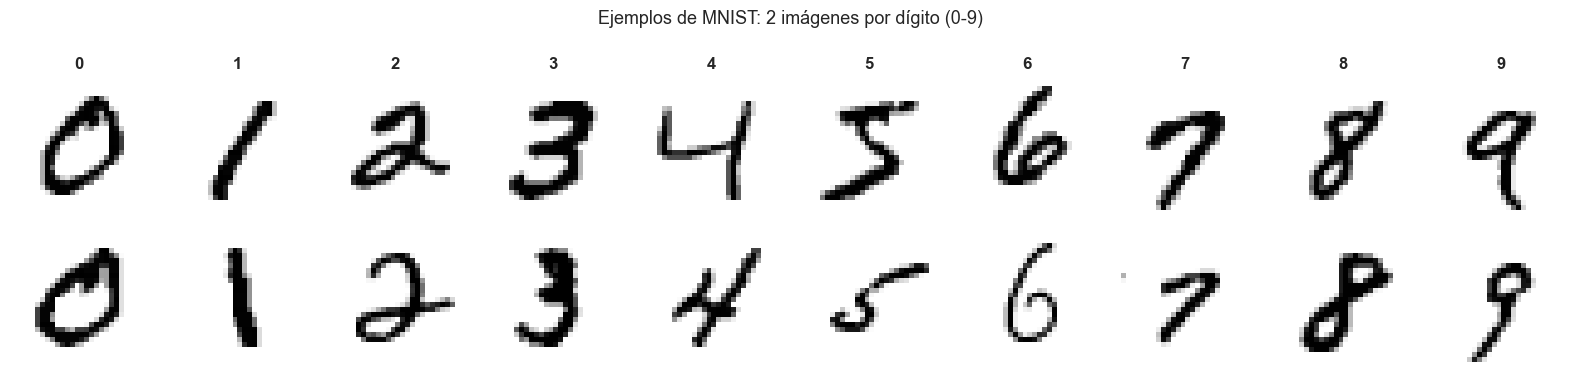

In [13]:
fig, axes = plt.subplots(2, 10, figsize=(16, 4))

for digito in range(10):
    indices = np.where(y_mnist == digito)[0][:2]
    for fila, idx in enumerate(indices):
        imagen = X_mnist[idx].reshape(28, 28)
        axes[fila, digito].imshow(imagen, cmap='gray_r')
        axes[fila, digito].axis('off')
        if fila == 0:
            axes[fila, digito].set_title(f'{digito}', fontsize=12, fontweight='bold')

plt.suptitle('Ejemplos de MNIST: 2 imágenes por dígito (0-9)', fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
X_train_full = X_mnist[:10000]
y_train_full = y_mnist[:10000]
X_test_m     = X_mnist[10000:15000]
y_test_m     = y_mnist[10000:15000]


X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1,   
    random_state=42
)

print(f'Train:      {X_train_m.shape[0]} imágenes')
print(f'Validation: {X_val_m.shape[0]} imágenes')
print(f'Test:       {X_test_m.shape[0]} imágenes')

# Normalizar píxeles al rango [0, 1]
# Los valores originales son 0-255; dividir por 255 los escala a [0, 1]
X_train_m = X_train_m / 255.0
X_val_m   = X_val_m   / 255.0
X_test_m  = X_test_m  / 255.0

print(f'\nRango de píxeles tras normalización: [{X_train_m.min():.1f}, {X_train_m.max():.1f}]')

Train:      9000 imágenes
Validation: 1000 imágenes
Test:       5000 imágenes

Rango de píxeles tras normalización: [0.0, 1.0]


## 3.4 Clasificación Multiclase con Regresión Logística

La Regresión Logística se extiende a múltiples clases mediante la estrategia **One-vs-Rest (OvR)**: entrena un clasificador binario por cada clase contra todas las demás, y predice la clase con mayor probabilidad.

Con 10 dígitos → **10 clasificadores binarios** internamente.

In [30]:
print('Entrenando Regresión Logística sobre MNIST...')
clf_lr_mnist = LogisticRegression(
    max_iter=50,
    multi_class='ovr',#One-vs-rest
    random_state=42,
)
clf_lr_mnist.fit(X_train_m, y_train_m)
acc_val = accuracy_score(y_val_m, clf_lr_mnist.predict(X_val_m))
acc_test = accuracy_score(y_test_m, clf_lr_mnist.predict(X_test_m))

print(f'Accuracy Val: {acc_val:.4f}  |  Test: {acc_test:.4f}')


Entrenando Regresión Logística sobre MNIST...


c:\Users\javier\Documents\escuela_ML_2026\Machine_Learning_Intro\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\javier\Documents\escuela_ML_2026\Machine_Learning_Intro\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\javier\Documents

Accuracy Val: 0.9210  |  Test: 0.8856


c:\Users\javier\Documents\escuela_ML_2026\Machine_Learning_Intro\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 3.5 Matriz de Confusión Multiclase

En clasificación con 10 clases la matriz de confusión es de **10×10**. Cada celda $(i,j)$ indica cuántas imágenes del dígito $i$ fueron clasificadas como dígito $j$. La diagonal principal son los **aciertos**.

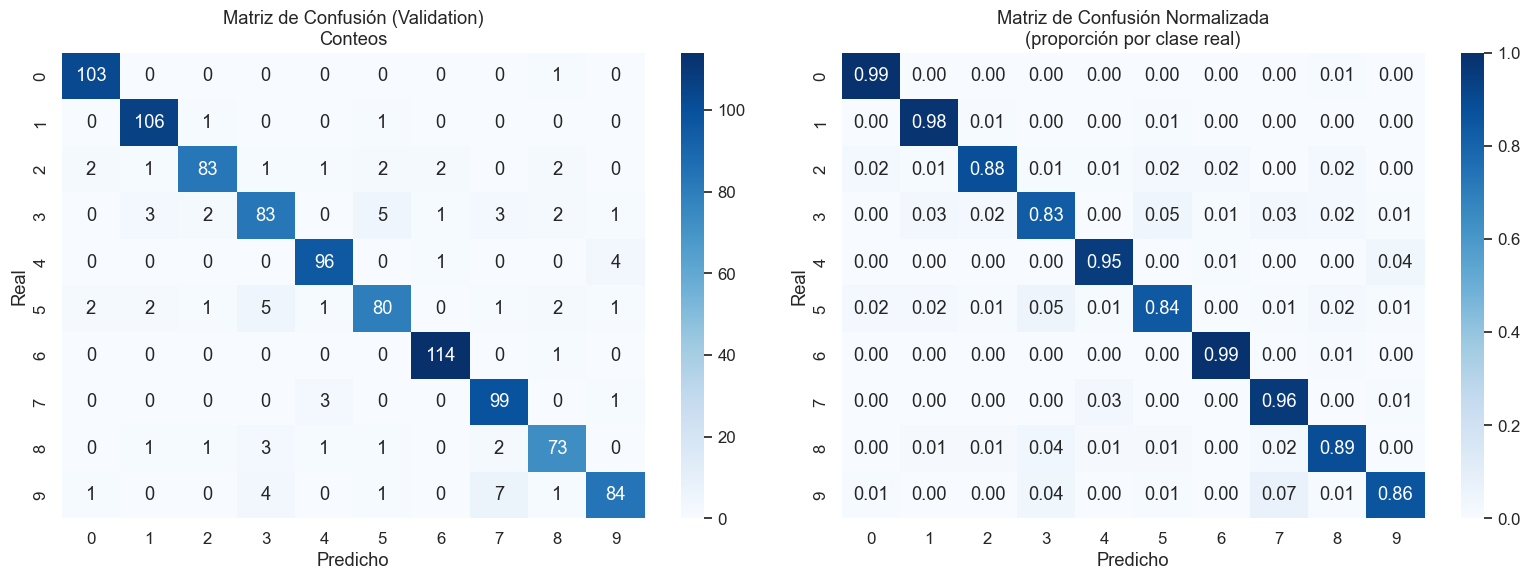

In [31]:
y_pred_val_m = clf_lr_mnist.predict(X_val_m)
cm = confusion_matrix(y_val_m, y_pred_val_m)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), ax=axes[0])
axes[0].set_title('Matriz de Confusión (Validation)\nConteos')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Matriz de Confusión Normalizada\n(proporción por clase real)')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

In [32]:
# Reporte completo
print('── Classification Report (Validation) ──────────────────────')
print(classification_report(y_val_m, y_pred_val_m,
                             target_names=[f'Dígito {i}' for i in range(10)]))

── Classification Report (Validation) ──────────────────────
              precision    recall  f1-score   support

    Dígito 0       0.95      0.99      0.97       104
    Dígito 1       0.94      0.98      0.96       108
    Dígito 2       0.94      0.88      0.91        94
    Dígito 3       0.86      0.83      0.85       100
    Dígito 4       0.94      0.95      0.95       101
    Dígito 5       0.89      0.84      0.86        95
    Dígito 6       0.97      0.99      0.98       115
    Dígito 7       0.88      0.96      0.92       103
    Dígito 8       0.89      0.89      0.89        82
    Dígito 9       0.92      0.86      0.89        98

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



## 3.6 Análisis de errores: ¿qué dígitos se confunden?

Visualizamos los casos donde el modelo se equivoca para entender sus limitaciones.

Total de errores en Test: 572 de 5000 (11.4%)


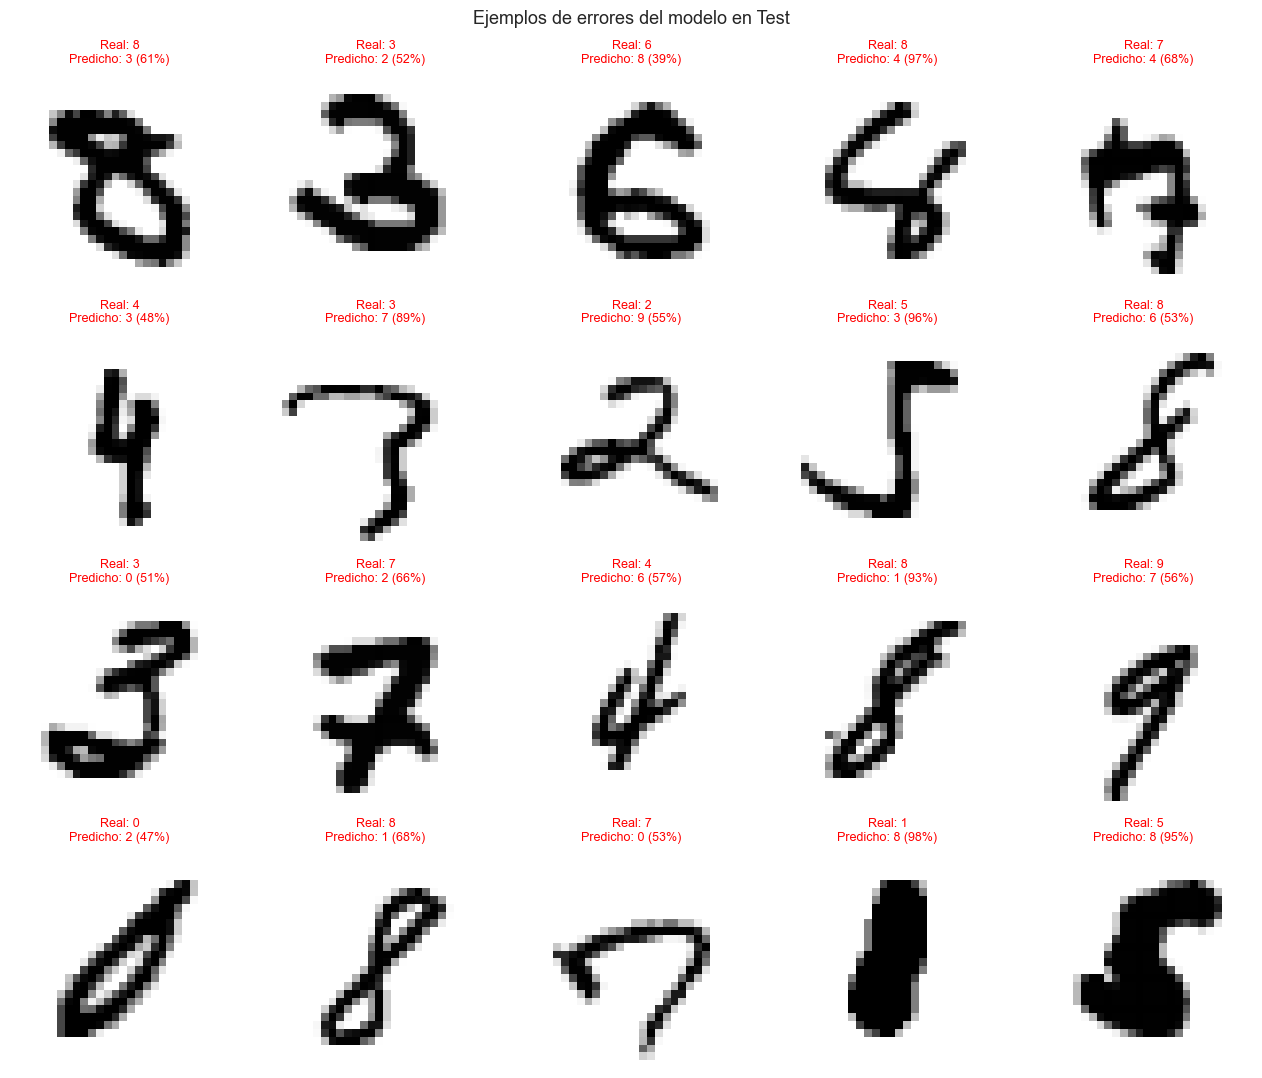

In [33]:
# Encontrar índices donde el modelo se equivocó
y_pred_test_m = clf_lr_mnist.predict(X_test_m)
errores = np.where(y_pred_test_m != y_test_m)[0]
print(f'Total de errores en Test: {len(errores)} de {len(y_test_m)} ({len(errores)/len(y_test_m)*100:.1f}%)')
fig, axes = plt.subplots(4, 5, figsize=(13, 11))
axes = axes.ravel()

for i, idx in enumerate(errores[:20]):
    imagen = X_test_m[idx].reshape(28, 28)
    real   = y_test_m[idx]
    pred   = y_pred_test_m[idx]
    prob   = clf_lr_mnist.predict_proba(X_test_m[idx:idx+1])[0, pred]

    axes[i].imshow(imagen, cmap='gray_r')
    axes[i].set_title(f'Real: {real}\nPredicho: {pred} ({prob:.0%})',
                      fontsize=9, color='red')
    axes[i].axis('off')

plt.suptitle('Ejemplos de errores del modelo en Test', fontsize=13)
plt.tight_layout()
plt.show()

## 3.7 Los pesos aprendidos: ¿qué 've' el modelo?

En regresión logística, cada clase tiene un vector de pesos de longitud 784. Podemos **visualizarlos como imágenes 28×28** para entender qué patrones visuales activan cada clasificador.

Forma de los pesos: (10, 784)  ← (10 clases × 784 píxeles)


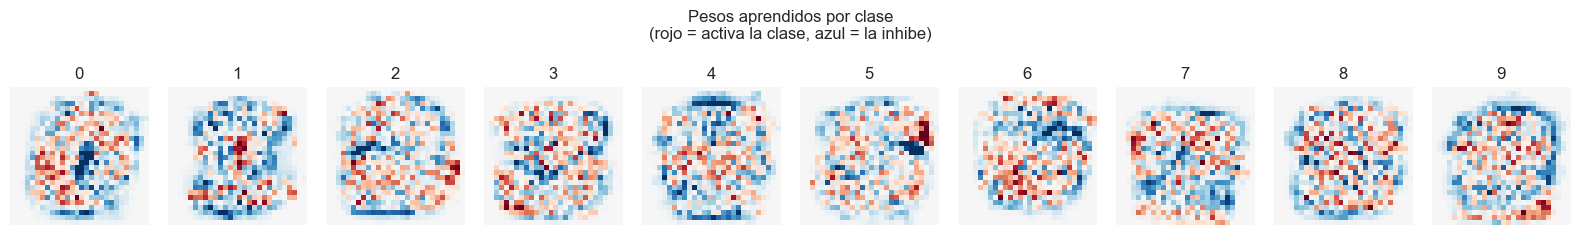

In [34]:
# clf_lr_mnist.coef_ tiene forma (10, 784) — un vector por clase
print(f'Forma de los pesos: {clf_lr_mnist.coef_.shape}  ← (10 clases × 784 píxeles)')

fig, axes = plt.subplots(1, 10, figsize=(16, 2.5))

for digito in range(10):
    pesos = clf_lr_mnist.coef_[digito].reshape(28, 28)
    # Mostrar: rojo=peso positivo (activa esta clase), azul=peso negativo (la inhibe)
    im = axes[digito].imshow(pesos, cmap='RdBu_r',
                              vmin=-pesos.std()*3, vmax=pesos.std()*3)
    axes[digito].set_title(f'{digito}', fontsize=12)
    axes[digito].axis('off')

plt.suptitle('Pesos aprendidos por clase\n(rojo = activa la clase, azul = la inhibe)', fontsize=12)
plt.tight_layout()
plt.show()

## 3.8 Evaluación Final en Test

## 3.9 Comparación: Regresión Logística vs Red Neuronal (MLP)

Para contexto, comparamos con una **red neuronal pequeña** (MLP: Multi-Layer Perceptron) también de sklearn:

In [35]:
clf_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=20,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=False
)
clf_mlp.fit(X_train_m, y_train_m)

acc_mlp_val  = accuracy_score(y_val_m,  clf_mlp.predict(X_val_m))
acc_mlp_test = accuracy_score(y_test_m, clf_mlp.predict(X_test_m))

print(f'MLP → Accuracy Val: {acc_mlp_val:.4f}  |  Test: {acc_mlp_test:.4f}')

MLP → Accuracy Val: 0.9530  |  Test: 0.9374


c:\Users\javier\Documents\escuela_ML_2026\Machine_Learning_Intro\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


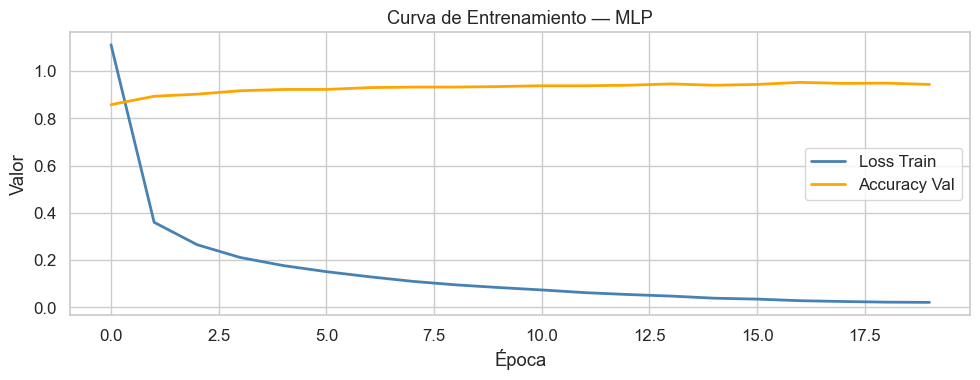

══════════════════════════════════════════════════
  Comparación de modelos en MNIST (Test)
══════════════════════════════════════════════════
  Regresión Logística (OvR):  88.56%
  MLP (128→64):               93.74%
══════════════════════════════════════════════════


In [36]:
# Curva de pérdida del MLP durante el entrenamiento
plt.figure(figsize=(10, 4))
plt.plot(clf_mlp.loss_curve_,      label='Loss Train',      color='steelblue', linewidth=2)
plt.plot(clf_mlp.validation_scores_,label='Accuracy Val',   color='orange',    linewidth=2)
plt.xlabel('Época')
plt.ylabel('Valor')
plt.title('Curva de Entrenamiento — MLP')
plt.legend()
plt.tight_layout()
plt.show()

# Tabla comparativa
print('══════════════════════════════════════════════════')
print('  Comparación de modelos en MNIST (Test)')
print('══════════════════════════════════════════════════')
print(f'  Regresión Logística (OvR):  {acc_test*100:.2f}%')
print(f'  MLP (128→64):               {acc_mlp_test*100:.2f}%')
print('══════════════════════════════════════════════════')

## Ejercicio Final

1. **Regresión**: cambia `sigma` (el nivel de ruido) a 0.5 y a 10.0. ¿Cómo afecta al R²? ¿Puede el modelo seguir recuperando los parámetros verdaderos?

2. **Clasificación binaria**: experimenta con el parámetro `C` en `LogisticRegression(C=...)` con valores `[0.01, 0.1, 1, 10]`. ¿Cómo cambia la frontera de decisión?

3. **MNIST**: el dígito 1 es el más fácil y el 8 el más difícil. ¿Puedes confirmar esto con la matriz de confusión? ¿Con qué otro dígito se confunde el 8 más frecuentemente?

In [ ]:
# Escribe tu solución aquí


Haz doble clic **aquí** para ver pistas.

<!--
# 3. Confusiones del dígito 8
mask_8 = y_test_m == 8
pred_8 = y_pred_test_m[mask_8]
print('Predicciones para el dígito 8:')
for d, count in zip(*np.unique(pred_8, return_counts=True)):
    if d != 8:
        print(f'  Confundido con {d}: {count} veces')
-->